In [19]:
pip install pytrends matplotlib pandas seaborn plotly

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq

#setup pytrend library and keyword define

In [27]:
from pytrends.request import TrendReq
pytrends = TrendReq(hl='en-US',tz=360)
keyword = "Data Scientist"

#Data Request

In [28]:
pytrends.build_payload([keyword], cat=0, timeframe='today 12-m', geo='', gprop='')

#Country wise interest

In [29]:
region_data=pytrends.interest_by_region()
region_data=region_data.sort_values(by = keyword,ascending=False).head(15)

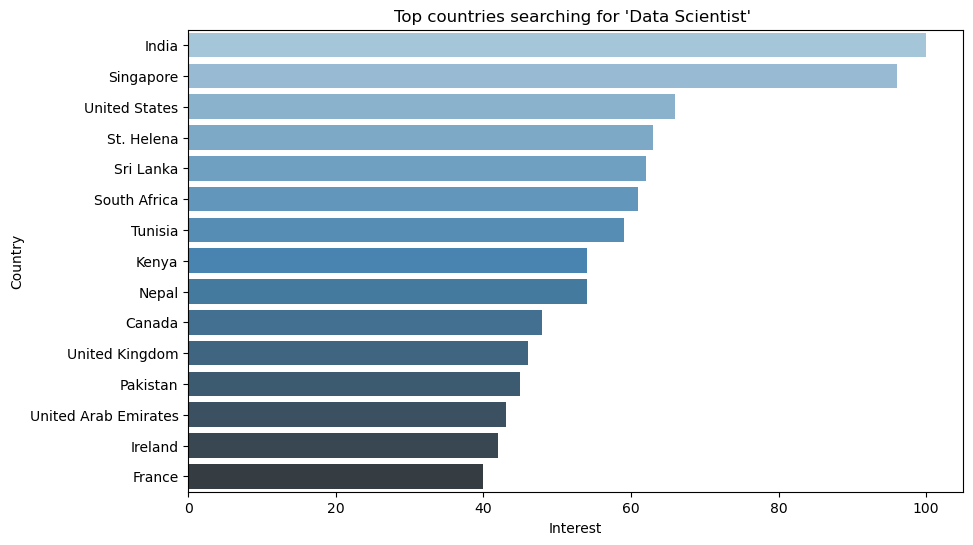

In [30]:
plt.figure(figsize=(10,6))
sns.barplot(x=region_data[keyword],y=region_data.index,palette="Blues_d")
plt.title(f"Top countries searching for '{keyword}' ")
plt.xlabel("Interest")
plt.ylabel("Country")
plt.show()

#world map

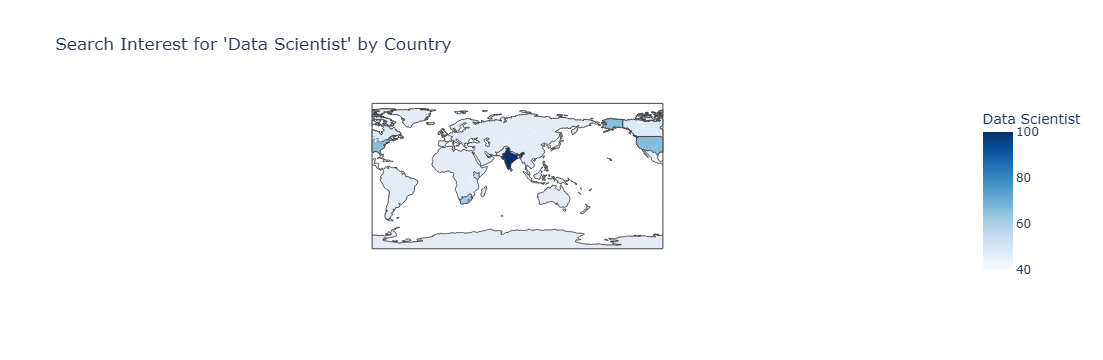

In [33]:
region_data=region_data.reset_index()
fig=px.choropleth(region_data,
                   locations='geoName',
                   locationmode='country names',
                   color=keyword,
                   title=f"Search Interest for '{keyword}' by Country",
                   color_continuous_scale='Blues')
fig.show()

#time wise interest

In [36]:
time_df=pytrends.interest_over_time()

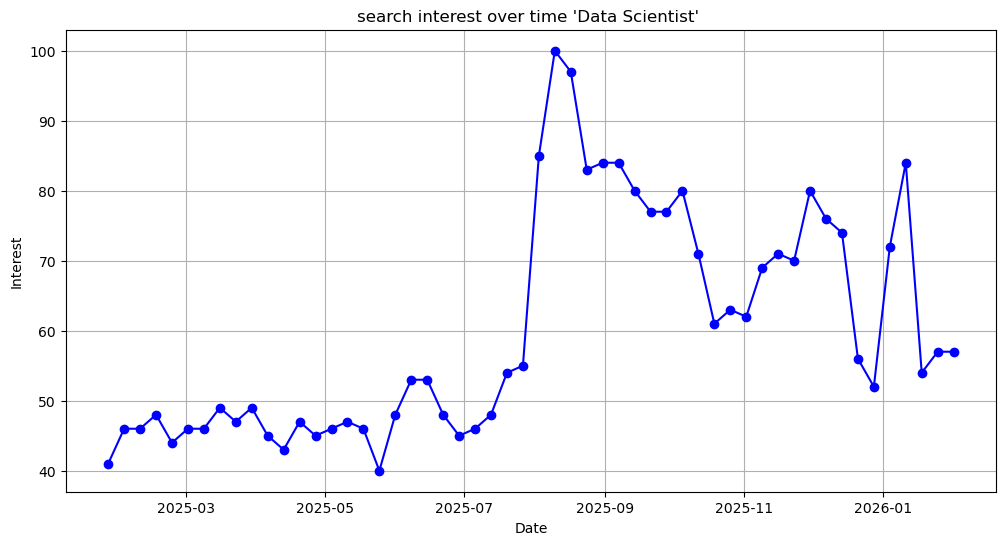

In [38]:
plt.figure(figsize=(12,6))
plt.plot(time_df.index,time_df[keyword],marker='o',color='blue')
plt.title(f"search interest over time '{keyword}' ")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.grid(True)

#multiple keywords compare

In [46]:
kw_list=["Data scientist", "Cloud computing", "Artificial intelligence", "Machine Learning"]
pytrends.build_payload(kw_list,cat=0,timeframe='today 12-m',geo='',gprop='')

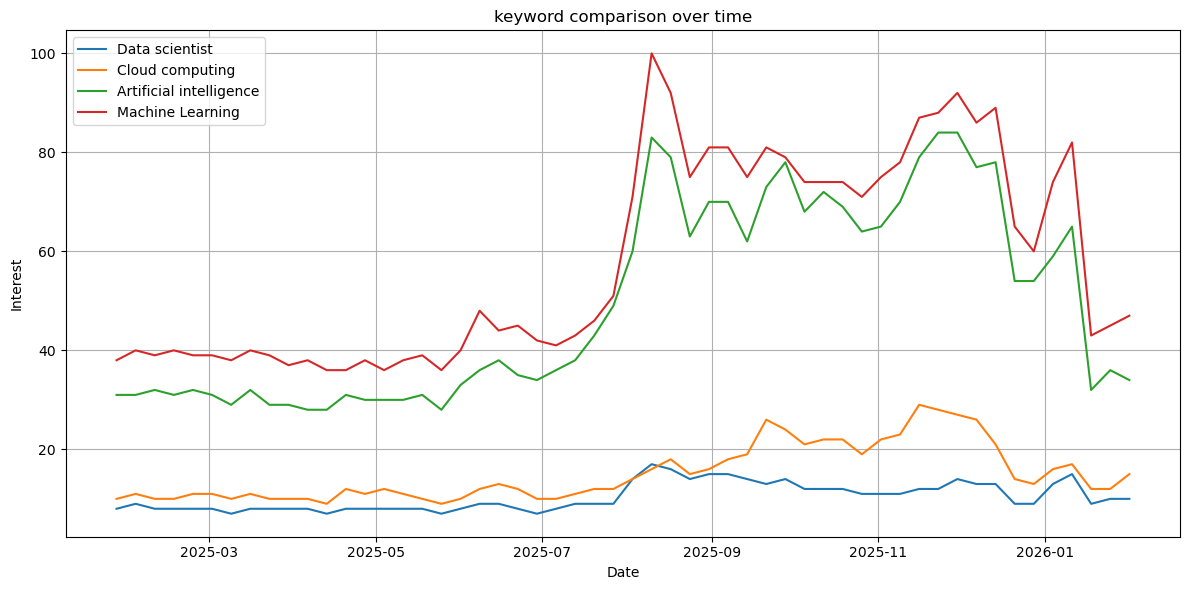

In [47]:
compare_df=pytrends.interest_over_time()

plt.figure(figsize=(12,6))
for kw in kw_list:
    plt.plot(compare_df.index,compare_df[kw],label=kw)

plt.title("keyword comparison over time")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()